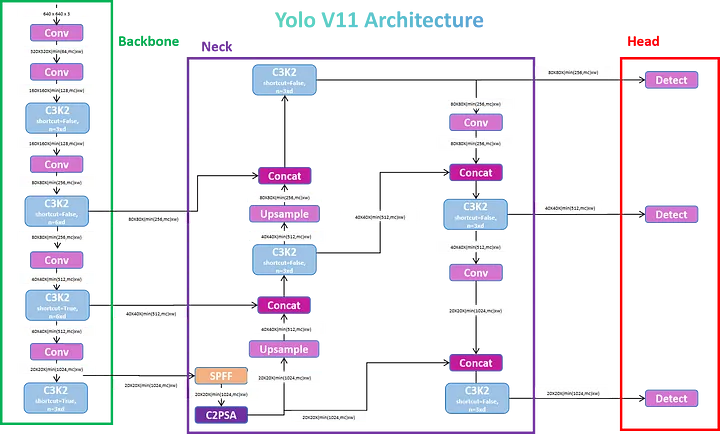 

# Content:
+ Yolo v11
+ Architecture
+ How it is different from other Yolo previous versions
+ Inferencing using pre trained model
+ training model on custom dataset

# Yolo v11
#### YoloV11 is a deep learning-based object detection algorithm. It is the latest iteration of the YOLO (You Only Look Once) series, which is widely used for real-time object detection tasks.

# Architecture
#### 1. **Backbone** : YOLOv11 uses a CSPDarkPaP (Cross Stage Partial Darknet with Parallel Aggregate Path) backbone, which is an enhanced version of the CSPDarknet series.
#### 2. **Neck** : The model features uses an enhanced Spatial Pyramid Pooling (SPP) neck with parallel aggregation for improved feature extraction.
#### 3. **Head** : The detection head utilizes a Decoupled Head with separate branches for object classification and bounding box regression.

# How it is different from other yolo models?
#### **Improved Feature Extraction** : Enhanced backbone and neck in YOLOv11.
#### **Better Classification** : Decoupled head in YOLOv11 enhances classification accuracy.
#### **Efficiency** : Optimizations for faster inference.

# Inferencing using pretrained model

## importing all libraries

In [1]:
import cv2
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
# os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "TRUE"

import supervision as sv
from ultralytics import YOLO
import wget

import torch
torch.cuda.empty_cache()

import matplotlib.pyplot as plt
# %matplotlib inline

## loading model from directory

In [2]:
model = YOLO("models/yolo11m.pt")

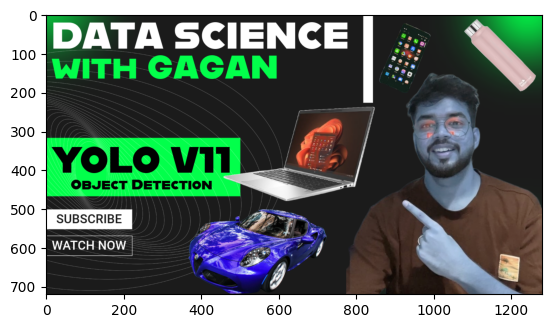

In [3]:
image = cv2.imread('yolov11.png')
plt.imshow(image)
# image = cv2.resize(image, (720, 480))

In [4]:
result = model(image)


0: 384x640 1 person, 1 car, 1 laptop, 1 remote, 1 toothbrush, 203.3ms
Speed: 2321.5ms preprocess, 203.3ms inference, 87.1ms postprocess per image at shape (1, 3, 384, 640)


In [5]:
result[0].boxes, model.names

(ultralytics.engine.results.Boxes object with attributes:
 
 cls: tensor([ 0., 63.,  2., 65., 79.], device='cuda:0')
 conf: tensor([0.9584, 0.9382, 0.9223, 0.8492, 0.8302], device='cuda:0')
 data: tensor([[7.7540e+02, 1.5153e+02, 1.2791e+03, 7.1240e+02, 9.5840e-01, 0.0000e+00],
         [4.5946e+02, 2.3914e+02, 8.4848e+02, 4.8437e+02, 9.3821e-01, 6.3000e+01],
         [3.6769e+02, 5.0105e+02, 7.2532e+02, 7.1620e+02, 9.2227e-01, 2.0000e+00],
         [8.5986e+02, 2.3417e+01, 9.9217e+02, 2.0391e+02, 8.4923e-01, 6.5000e+01],
         [1.0790e+03, 1.3211e+01, 1.2657e+03, 2.0045e+02, 8.3024e-01, 7.9000e+01]], device='cuda:0')
 id: None
 is_track: False
 orig_shape: (720, 1280)
 shape: torch.Size([5, 6])
 xywh: tensor([[1027.2583,  431.9669,  503.7231,  560.8644],
         [ 653.9675,  361.7538,  389.0172,  245.2296],
         [ 546.5062,  608.6276,  357.6304,  215.1475],
         [ 926.0126,  113.6661,  132.3058,  180.4978],
         [1172.3518,  106.8288,  186.7183,  187.2363]], device='cu

### plotting bbox on image

##### using cv2

In [ ]:
for box in result[0].boxes:
    bbox = box.xyxy[0].cpu().numpy()
    x1, y1, x2, y2 = int(bbox[0]), int(bbox[1]), int(bbox[2]), int(bbox[3])
    img = cv2.rectangle(image, (x1, y1), (x2, y2), color = (0, 250, 0), thickness=2)
    img = cv2.putText(img, text=f'{model.names[int(box.cls)]}', org = (x1, y1) , color = (250, 0, 0), fontScale=6, fontFace=cv2.FONT_HERSHEY_DUPLEX, thickness = 5)

img = cv2.resize(img, (720, 480))
cv2.imshow('Detected Image', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

##### using sv

In [6]:
detections = sv.Detections.from_ultralytics(result[0])    
bounding_box_annotator = sv.BoundingBoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = bounding_box_annotator.annotate(
    scene=image, detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)
# annotated_image = cv2.resize(annotated_image, (720, 480))
cv2.imshow('YOLO', annotated_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.


#### Inference on live videos

In [ ]:
model = YOLO('models/yolo11x.pt')

In [ ]:
cap = cv2.VideoCapture(0)
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame)[0]
    detections = sv.Detections.from_ultralytics(results)
    
    bounding_box_annotator = sv.BoundingBoxAnnotator()
    label_annotator = sv.LabelAnnotator()
    
    annotated_image = bounding_box_annotator.annotate(
        scene=frame, detections=detections)
    annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)
    cv2.imshow('YOLO', annotated_image)
    
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

## Training model on custom dataset

### downloading data from roboflow

In [ ]:
# !pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="")
project = rf.workspace("gagan-gupta-ia5gb").project("demo-mdzxd")
version = project.version(1)
dataset = version.download("yolov11")
                

In [ ]:
print(dataset.location)

In [ ]:
!sed -i '$d' {dataset.location}/data.yaml   # Delete the last line
!sed -i '$d' {dataset.location}/data.yaml   # Delete the second-to-last line
!sed -i '$d' {dataset.location}/data.yaml   # Delete the third-to-last line

!echo 'test: ../test/images' >> {dataset.location}/data.yaml
!echo 'train: ../train/images' >> {dataset.location}/data.yaml
!echo 'val: ../valid/images' >> {dataset.location}/data.yaml

In [ ]:
model_to_train = YOLO('models/yolo11n.pt')

In [ ]:
trained_model = model.train(data="object_detection_remote-3/data.yaml", epochs=100, imgsz=640)

### loading trained model

In [ ]:
trained_model = YOLO('models/best (1).pt')

### checking evaluation metrics

In [ ]:
metrics = trained_model.val()

In [ ]:
metrics.box.map, metrics.box.map50, metrics.box.map75

## Inferencing using trained model

In [ ]:
cap = cv2.VideoCapture(1)
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = trained_model(frame)[0]
    # for result in results:
    for box in results.boxes:
        cnf = box.conf.cpu().numpy()[0]
        if cnf > 0.75:
            bbox = box.xyxy[0].cpu().numpy()
            x1, y1, x2, y2 = int(bbox[0]), int(bbox[1]), int(bbox[2]), int(bbox[3])
            frame = cv2.rectangle(frame, (x1, y1), (x2, y2), color = (0, 250, 0), thickness=2)
            frame = cv2.putText(frame, text=f'{trained_model.names[int(box.cls)]}', org = (x1, y1) , color = (250, 0, 0), fontScale=1, fontFace=cv2.FONT_HERSHEY_DUPLEX, thickness = 5)

    img = cv2.resize(frame, (720, 480))
    cv2.imshow('YOLO', img)
    
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()